In [9]:
!pip install contextily
!pip install geodatasets
!pip install ipywidgets

   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/914.9 kB ? eta -:--:--
   ---------------------------------- ----- 786.4/914.9 kB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 914.9/914.9 kB 1.9 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.2 MB 2.8 MB/s eta 0:00:01
   ------------------- -------------------- 1.0/2.2 MB 3.0 MB/s eta 0:00:01
   --------------------------------- ------ 1.8/2.2 MB 3.2 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 3.2 MB/s  0:00:00

   ------------- -------------------------- 1/3 [jupyterlab_widgets]
   ------------- -------------------------- 1/3 [jupyterlab_widgets]



ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\Mahlatse\\anaconda3\\envs\\white-mussel-wcrlobster_env\\share\\jupyter\\labextensions\\@jupyter-widgets\\jupyterlab-manager\\static\\vendors-node_modules_d3-color_src_color_js-node_modules_d3-format_src_defaultLocale_js-node_m-09b215.2643c43f22ad111f4f82.js.map'



In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.ops import unary_union
import contextily as cx
import geodatasets

In [22]:
# ---------------------------------------------------
# 1. Load base coastline / land polygon
# ---------------------------------------------------
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

In [23]:
sa = world[world["ADMIN"] == "South Africa"].to_crs(epsg=3857)

# dissolve into single geometry (modern replacement for unary_union)
sa_land_geom = sa.geometry.union_all()

sa_land_gdf = gpd.GeoDataFrame(
    geometry=[sa_land_geom],
    crs=sa.crs
)

In [24]:
sites = {
    "Lamberts Bay": (18.29, -32.10),
    "Elands Bay": (18.34, -32.31),
    "Dwarskersbos": (18.24, -32.66),
    "Paternoster": (17.89, -32.81),
    "Britannia Bay": (17.93, -32.75),
    "Yzerfontein": (18.16, -33.33),
    "Bokpunt": (18.08, -33.57),
}

gdf_sites = gpd.GeoDataFrame(
    {"name": list(sites.keys())},
    geometry=[Point(xy) for xy in sites.values()],
    crs="EPSG:4326"
).to_crs(epsg=3857)

In [25]:
hull = gdf_sites.geometry.union_all().convex_hull
study_area = hull.buffer(30000)  # 30 km buffer (meters in EPSG:3857)

# Remove land from study area (ocean-only mask)
ocean_only = study_area.difference(sa_land_geom)

gdf_ocean = gpd.GeoDataFrame(
    geometry=[ocean_only],
    crs=sa.crs
)

In [26]:
west_bbox = gpd.GeoDataFrame(
    geometry=[Point(18, -33)], crs="EPSG:4326"
).to_crs(epsg=3857).geometry[0]

# manual extent in meters (stable zoom window)
minx, miny = gdf_sites.total_bounds[0] - 100000, gdf_sites.total_bounds[1] - 200000
maxx, maxy = gdf_sites.total_bounds[2] + 100000, gdf_sites.total_bounds[3] + 100000


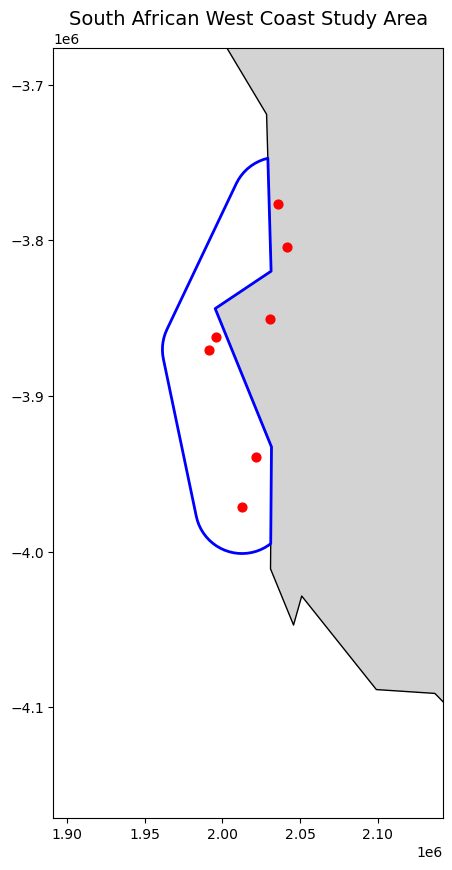

In [27]:
fig, ax = plt.subplots(figsize=(10, 10))

# land
sa_land_gdf.plot(ax=ax, color="lightgrey", edgecolor="black")

# ocean study area
gdf_ocean.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=2)

# sites
gdf_sites.plot(ax=ax, color="red", markersize=40)

# zoom to West Coast
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title("South African West Coast Study Area", fontsize=14)

plt.show()